In [1]:
from LIMxCMBL.kernels import *
from LIMxCMBL.experiments import *

/home/users/delon/.local/lib/python3.9/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [2]:
import matplotlib.pyplot as plt

In [3]:
dchi = np.mean(np.diff(chis))

In [4]:
kernels = {}
kernels['CII'] = np.array(KI)
kernels['CO'] = np.array(KI_CO)
kernels['Lya'] = np.array(KI_Lya)
kernels['HI'] = np.array(KI_HI)

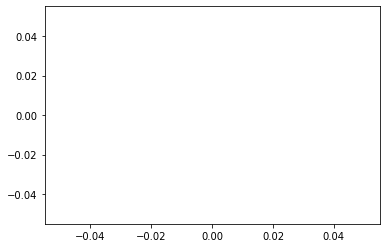

In [5]:
import matplotlib.pyplot as plt
from matplotlib import colors

plt.plot()
plt.rcParams.update({
    "text.usetex": True,
    "font.size": 10,
    "font.family" : "serif",
    'figure.constrained_layout.use':True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'hatch.linewidth':0.1,
    'figure.figsize': (6, 6/1.618),
    'figure.constrained_layout.use': False,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

In [6]:
e_order = ['CHIME',
          'HETDEX',
          'COMAP',
          'CCAT-prime',
          'SPHEREx']

In [7]:
e_colors = {
    'CHIME': '#8932B8',
    'HETDEX': '#3C44AA',
    'COMAP': '#5E7C16',
    'SPHEREx': '#B02E26',
    'CCAT-prime':'#F9801D',
}


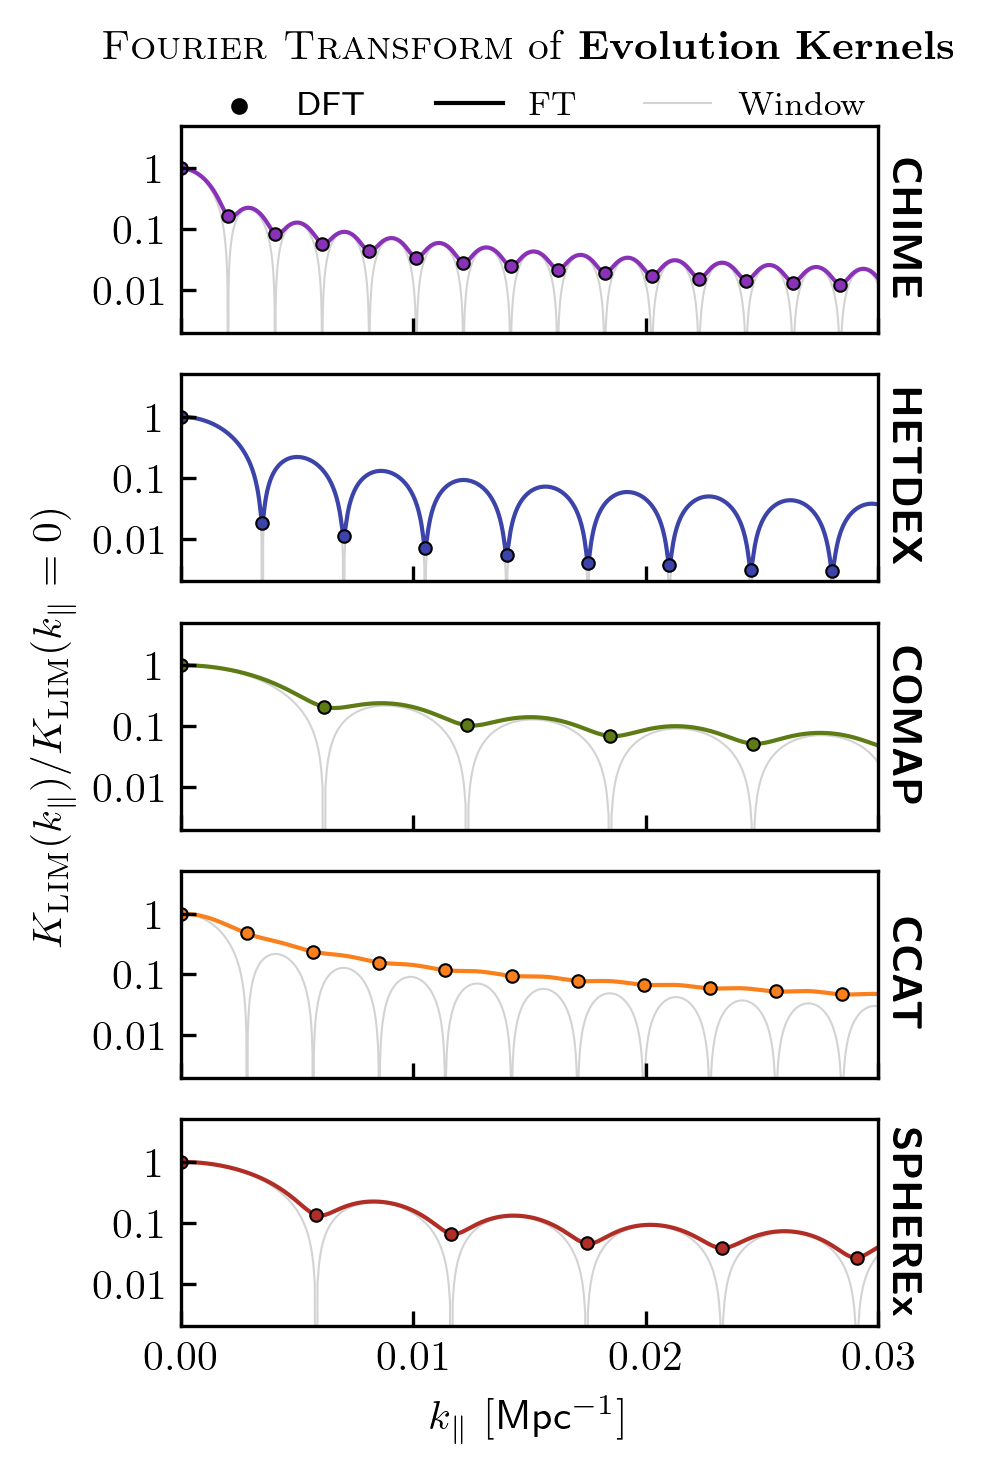

In [37]:
fig, axs = plt.subplots(nrows = len(experiments), ncols = 1, sharex = True, 
                       figsize=(3, 5.3),
                       facecolor='w', dpi=300)


for i, e in enumerate(e_order):
    experiment = e
    ax = axs[i]
    zmin = experiments[experiment]['zmin']
    zmax = experiments[experiment]['zmax']
    line_str = experiments[experiment]['line_str']

    chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
    chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))
    
    idx_window = np.where((chis >= chimin) & (chis <= chimax))
    window = np.zeros_like(chis)
    window[idx_window] = 1
    
    unwindowedKI = kernels[line_str]
    
    
    
    
    kernel_without_window = unwindowedKI[idx_window]
    kernel_without_window_k = np.fft.rfft(kernel_without_window)
    ks1 = 2*np.pi*np.fft.rfftfreq(len(kernel_without_window), d=dchi)
  
    #pad to align modes
    kernel_with_window = unwindowedKI * window
    kernel_with_window_mean = np.mean(unwindowedKI[idx_window]) * window

    target_length = 100 * len(kernel_without_window)
    current_length = len(kernel_with_window)

    if target_length > current_length:
        padding_needed = target_length - current_length
        kernel_with_window = np.pad(kernel_with_window, (0, padding_needed), mode='constant', constant_values=0)
        kernel_with_window_mean = np.pad(kernel_with_window_mean, (0, padding_needed), mode='constant', constant_values=0)
    
    kernel_with_window_k = np.fft.rfft(kernel_with_window)
    kernel_with_window_mean_k = np.fft.rfft(kernel_with_window_mean)

    ks0 = 2*np.pi*np.fft.rfftfreq(len(kernel_with_window), d=dchi)   

    
    ax.plot(ks0, np.abs(kernel_with_window_mean_k)/np.abs(kernel_without_window_k[0]), 
            lw=0.5, c='lightgrey',
            ls='-',
            zorder=1,)

    ax.plot(ks0, np.abs(kernel_with_window_k)/np.abs(kernel_without_window_k[0]), 
            lw=1, c=e_colors[e],
            ls='-',
            zorder=1,)
    ax.scatter(ks1, np.abs(kernel_without_window_k)/np.abs(kernel_without_window_k[0]), 
               lw=0.5, edgecolor='k',
               marker='.', facecolor=e_colors[e],)
    
    ax.scatter([100], [100],label='{\sf DFT}',
               marker='.', facecolor='k')

    ax.plot([100,100], [100, 100],
            lw=1, c='k',
            ls='-',
            zorder=1,
               label='FT')

    ax.plot([100,100], [100, 100],
            lw=0.5, c='lightgrey',
            ls='-',
            zorder=1,
               label='Window')


    ax.set_yscale('log')
    
    
    _etxt = experiment
    if(experiment == 'CCAT-prime'):
        _etxt = 'CCAT'
    ax.text(1.01, 0.5, r'\textsf{\textbf{%s}}'%(_etxt), 
            transform=ax.transAxes, 
            ha='left', va='center',
            fontsize=10,
            rotation=-90)

    ax.set_yticks([1, 0.1, 0.01])
    ax.set_yticklabels([1, 0.1, 0.01])
    
    
    _idx = np.where(ks1 < 5e-2)
    ax.set_ylim(1e-2/5, 5)

    
    if(i==0):

        #figure config
        leg = axs[0].legend(frameon=False, ncols = 3, 
                        bbox_to_anchor=(0., 0.96, 1., .5),
                        borderaxespad=0.,
                        loc = 'lower right',
                        bbox_transform=ax.transAxes,
                        fontsize = 8,)




    ax.yaxis.set_minor_locator(plt.NullLocator())    
axs[2].set_ylabel(r'$K_{\rm LIM}(k_\parallel) / K_{\rm LIM}(k_\parallel = 0)$')


axs[0].set_title(r'\textsc{Fourier Transform} of \textbf{Evolution Kernels}'+'\n',
                fontsize=10,)

plt.xlabel(r'$k_\parallel$ [{\sf Mpc}${}^{-1}$]')
plt.xlim(0, 3e-2)
plt.savefig('figures/017.001.pdf',bbox_inches='tight')

In [9]:
lo_DFT

<function LIMxCMBL.kernels.lo_DFT(alpha, chimin, chimax, m, eps=1e-08)>

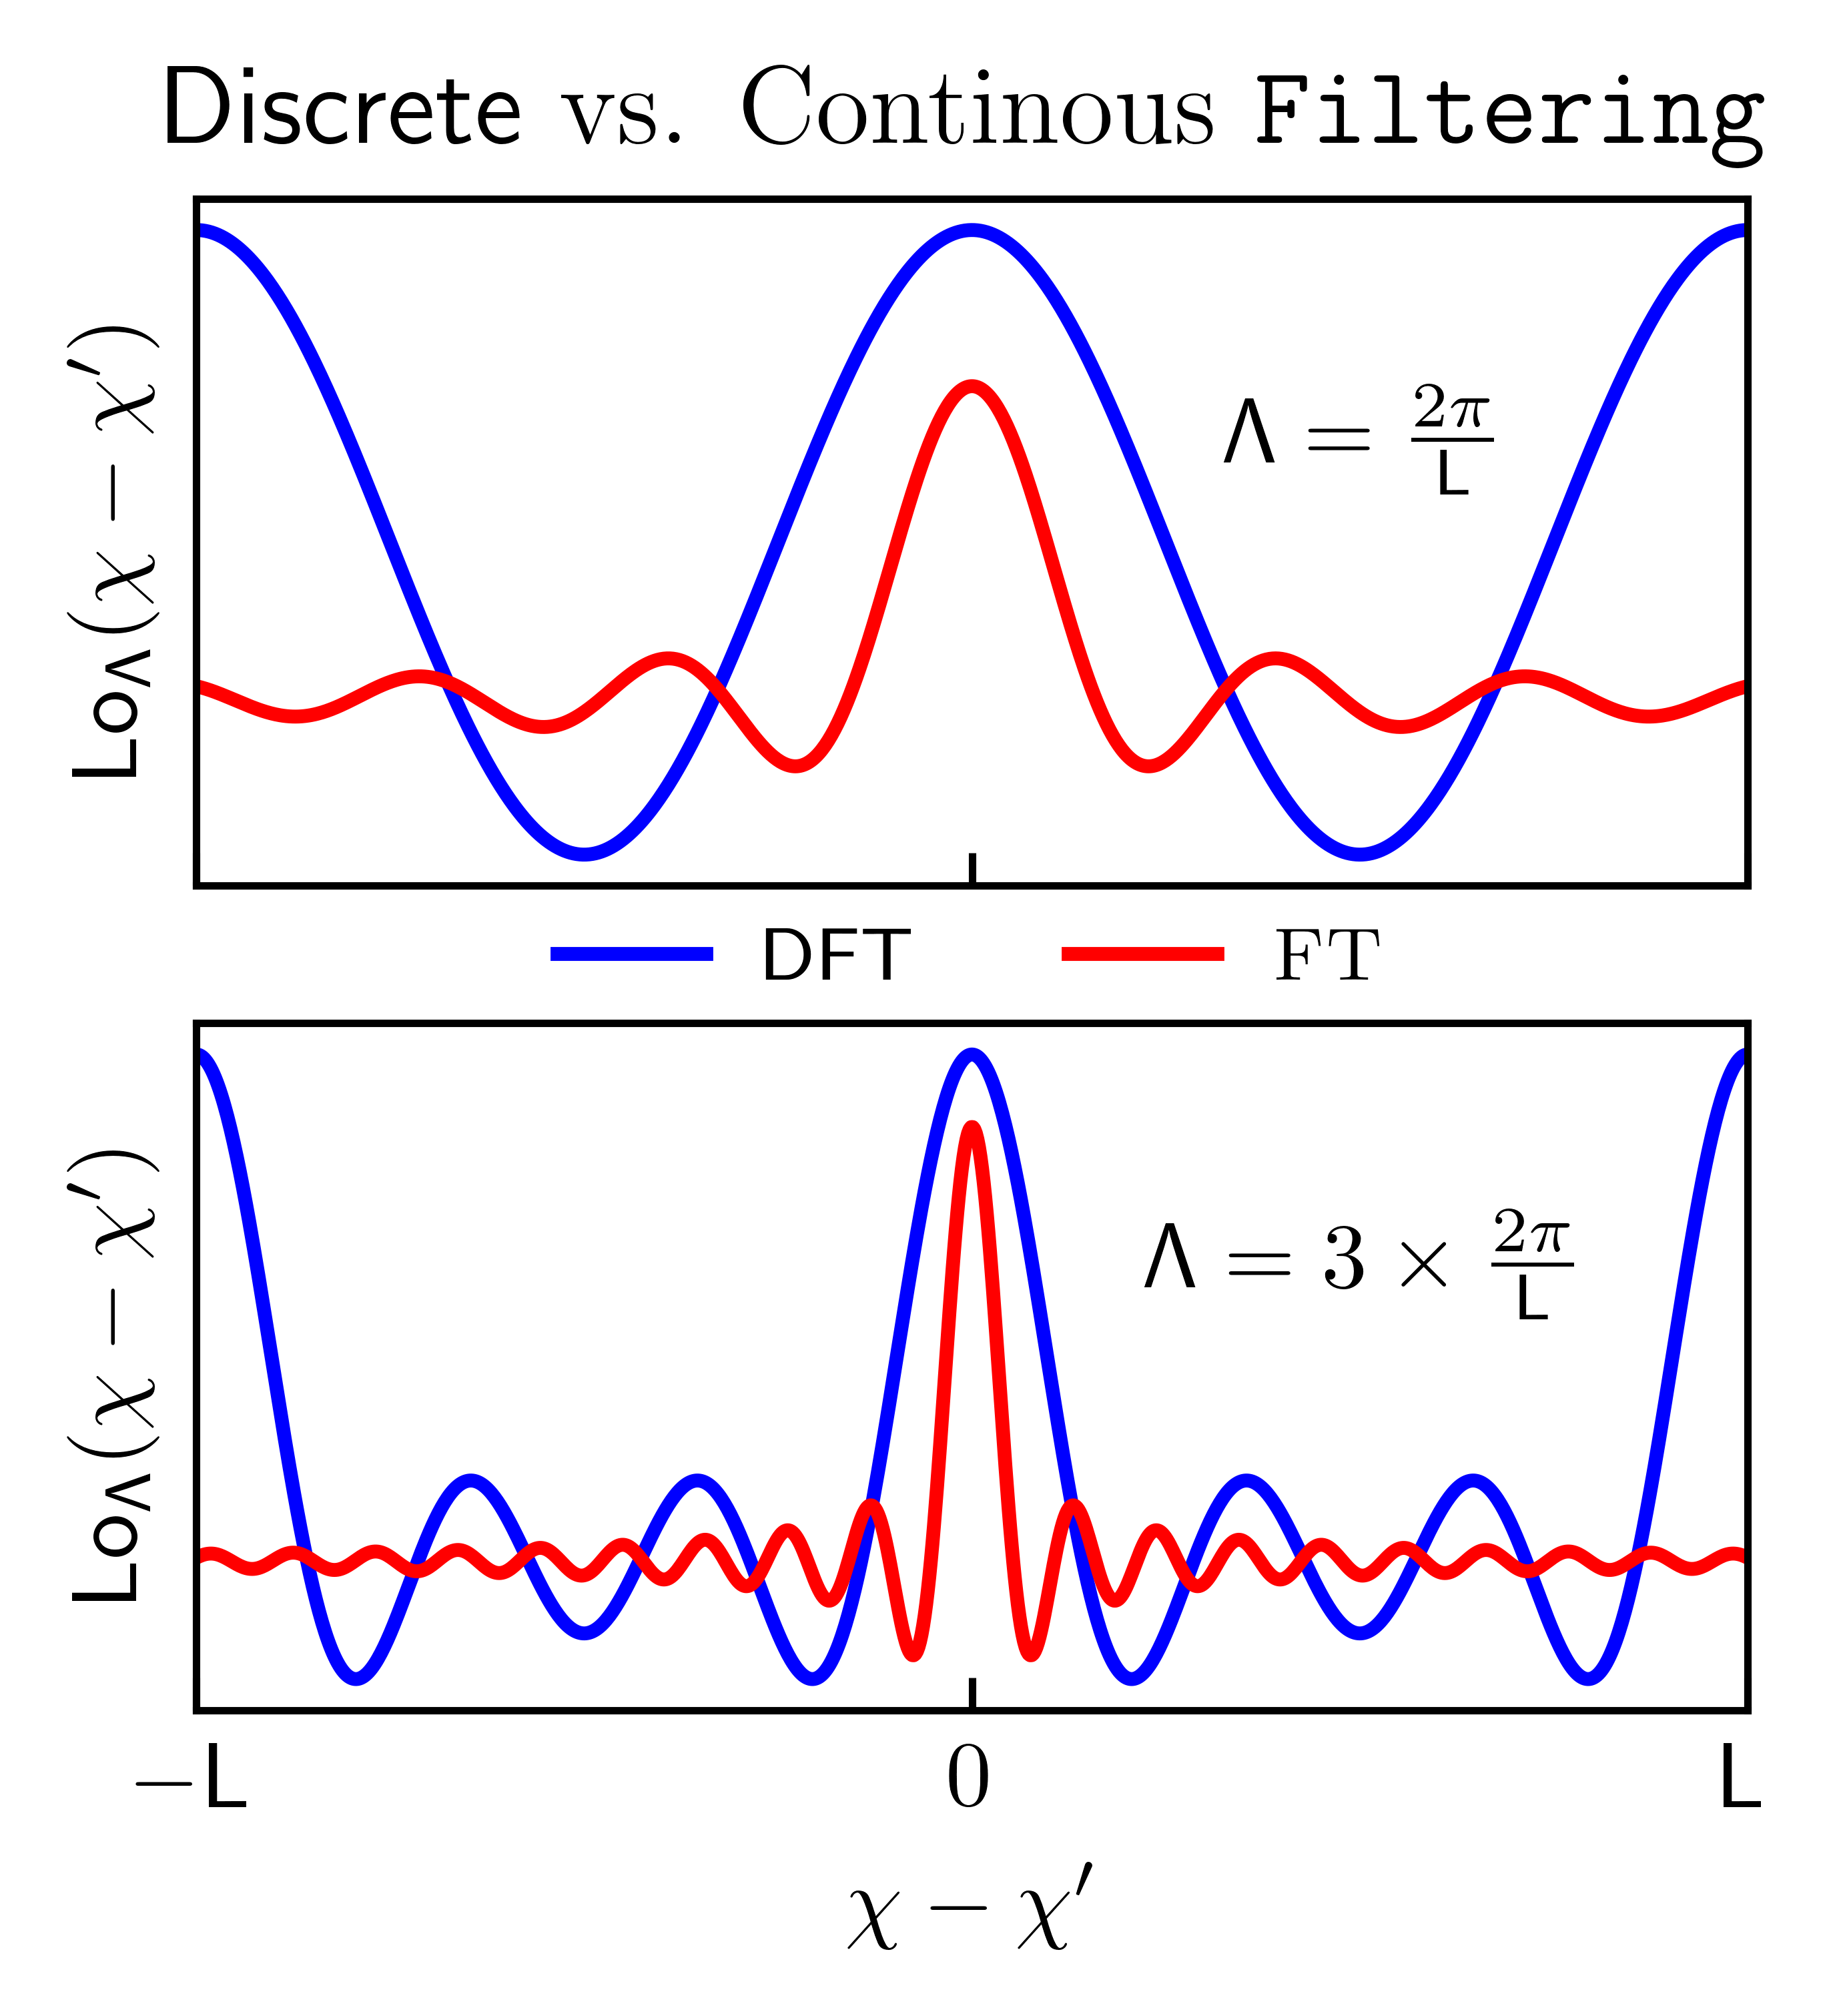

In [36]:
fig, axs = plt.subplots(nrows = 2, ncols = 1, dpi = 1000, figsize=(3, 3), sharex=True,)

alpha = np.linspace(-1, 1, 1000)
_L = 1
kF = 2*np.pi

m = 1
axs[0].plot(alpha, lo_DFT(alpha, -0.5, 0.5, m), c='b')
axs[0].plot(alpha, m * kF / np.pi * np.sinc(m * kF * alpha), c='r')

m = 3
axs[1].plot(alpha, lo_DFT(alpha, -0.5, 0.5, m), c='b', label=r'{\sf DFT}')
axs[1].plot(alpha, m * kF / np.pi * np.sinc(m * kF * alpha), c='r', label=r'{\sc FT}')



for ax in axs:
    ax.set_yticks([])
    ax.set_ylabel(r"${\sf Lo}_{\sf \Lambda}(\chi-\chi')$")
plt.xlim(-1, 1)
plt.xticks([-1, 0, 1])
axs[1].set_xticklabels([r'$-{\sf L}$', 0, r'${\sf L}$'])
axs[0].set_title(r'{\sf Discrete} vs. {Continous} \texttt{Filtering}')
axs[1].set_xlabel(r"$\chi - \chi'$")

#figure config
leg = axs[1].legend(frameon=False, ncols = 3, 
                bbox_to_anchor=(0., 1, 1., .5),
                borderaxespad=0.,
                loc = 'lower center',
                bbox_transform=ax.transAxes,
                fontsize = 8,)

axs[0].text(x = 0.75, y = 0.65, s=r'${\sf \Lambda} = \frac{2\pi}{\sf L}$',
            horizontalalignment = 'center', verticalalignment='center',
                       transform=axs[0].transAxes, 
)

axs[1].text(x = 0.75, y = 0.65, s=r'${\sf \Lambda} = 3\times\frac{2\pi}{\sf L}$',
            horizontalalignment = 'center',verticalalignment='center',             transform=axs[1].transAxes, 
)

plt.savefig('figures/017.001.LO.pdf',bbox_inches='tight')